In [1]:
import pyBigWig
import sklearn.metrics
from sklearn.metrics import roc_auc_score

In [53]:
auprcs = []
aurocs = []
for foldn in ["fold0", "fold1", "fold2", "fold3", "fold4"]:
#for foldn in ["fold0"]:

    import pandas as pd
    #foldn="fold0"
    #bed_annotate = "/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/auprc_curves/K562/idr_overlap_peak_blacklist_annotated_"+foldn+"_dnase.bed"
    bed_annotate = "/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/auprc_curves/K562/idr_overlap_peak_blacklist_annotated_"+foldn+".bed"

    chr1_binned = pd.read_csv(bed_annotate, sep="\t", names=["chr", "start", "end", "idr", "idr_f", "idr_t", "idr_w", "idr_frac", 
                                                             "bkt", "op"])
    chr1_binned = chr1_binned[:-1]
    print(chr1_binned.shape)

    #chr1_binned["mappability"] = mappability
    chr1_binned["label"] = 0
    chr1_binned.loc[chr1_binned["idr"]==1, "label"] =1
    print(sum(chr1_binned["label"]))
    
    import numpy as np
    chrm = None
    values = []
    chromsize={}
    chroms = chr1_binned['chr'].unique().tolist()

    for chrm in chroms:
        bww="/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/auprc_curves/K562/ATAC_uncorrected/K562_"+foldn+"_"+chrm+"_w_bias.bw"
        pred_bigwig = pyBigWig.open(bww,"r")
        chrmsz = pred_bigwig.chroms(chrm)
        print(chrm, chrmsz)


        filtered_df = chr1_binned[chr1_binned['chr'] == chrm]
        # Find the maximum value in the 'value' column
    #     max_value = filtered_df['end'].max()
    #     print(chrm, chrmsz, max_value)
        chromsize[chrm] = [filtered_df.shape[0], chrmsz]

        all_val = np.nan_to_num(pred_bigwig.values(chrm, 0, chrmsz))
        atac = [sum(all_val[i:i+100]) for i in range(557,chromsize[chrm][1], 100)][0:chromsize[chrm][0]]
        values.extend(atac)
    chr1_binned["atac"] = values
    
    import numpy as np
    import gzip

    mappability = []
    for chrm in chroms:

        with gzip.open("/mnt/lab_data2/anusri/chrombpnet/reference/mappability/"+chrm+'.uint8.unique.gz', 'rb') as tmp_uMap:
            uMapdata = np.frombuffer(tmp_uMap.read(), dtype=np.uint8)

        pos_vec = (uMapdata>0)&(uMapdata<=101)
        pos_vec = pos_vec.astype(int)
        neg_vec = np.roll(pos_vec, 100)
        neg_vec[0:100] = 0

        print(set(pos_vec))
        print(len(uMapdata))
        print(sum(pos_vec))

        total_map=pos_vec+neg_vec
        mappability.extend([sum(total_map[i:i+100])/200 for i in range(557,chromsize[chrm][1], 100)][0:chromsize[chrm][0]])

    chr1_binned["mappability"] = mappability
    print(sum(chr1_binned["idr"]==1))
    chr1_binned=chr1_binned[chr1_binned["bkt"]==0]
    chr1_binned = chr1_binned[~((chr1_binned["idr_frac"]>0) & (chr1_binned["idr_frac"]<1.0))]
    chr1_binned = chr1_binned[~((chr1_binned["op"]==1) & (chr1_binned["idr"]==0))]
    print(chr1_binned.shape)
    chr1_binned = chr1_binned[chr1_binned["mappability"]>0.5]
    aupr=sklearn.metrics.average_precision_score(chr1_binned["label"],chr1_binned["atac"])
    auproc=roc_auc_score(chr1_binned["label"],  abs(chr1_binned["atac"]))
    print(foldn,np.round(aupr,2),auproc)
    print(sum(chr1_binned["label"])/chr1_binned.shape[0])
    auprcs.append(aupr)
    aurocs.append(auproc)
    
    target_recall=0.7
    precision, recall, thresholds = sklearn.metrics.precision_recall_curve(chr1_binned["label"].astype(int), abs(chr1_binned["atac"]))
    recall_diff = np.abs(recall - target_recall)
    best_threshold_index = np.argmin(recall_diff)
    best_threshold = thresholds[best_threshold_index]

    # Calculate FDR at the best threshold
    tp = np.sum((abs(chr1_binned["atac"]) >= best_threshold) & (chr1_binned["label"].astype(int) == 1))
    fp = np.sum((abs(chr1_binned["atac"]) >= best_threshold) & (chr1_binned["label"].astype(int) == 0))

    fdr = fp / (fp + tp)
    print("FDR at 70% recall", fdr)

(6180564, 10)
18695
chr1 248956422
chr3 198295559
chr6 170805979
{0, 1}
248956422
219161958
{0, 1}
198295559
193185515
{0, 1}
170805979
166067589
18695
(5795981, 13)
fold0 0.42 0.9805701799708305
0.0034111449836988807
FDR at 70% recall 0.7870338720966193
(6160630, 10)
14984
chr2 242193529
chr8 145138636
chr9 138394717
chr16 90338345
{0, 1}
242193529
232311931
{0, 1}
145138636
139766879
{0, 1}
138394717
110801461
{0, 1}
90338345
74517179
14984
(5833681, 13)
fold1 0.43 0.9831840931986112
0.0028023462774240493
FDR at 70% recall 0.7839258114374034
(6177924, 10)
13895
chr4 190214555
chr11 135086622
chr12 133275309
chr15 101991189
chrY 57227415
{0, 1}
190214555
184680542
{0, 1}
135086622
129223817
{0, 1}
133275309
129335539
{0, 1}
101991189
77315909
{0, 1}
57227415
15127684
13895
(5842982, 13)
fold2 0.42 0.9835565706371082
0.002700185875882026
FDR at 70% recall 0.7880742742568215
(6180123, 10)
14875
chr5 181538259
chr10 133797422
chr14 107043718
chr18 80373285
chr20 64444167
chr22 50818468
{

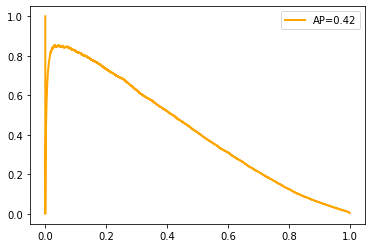

In [29]:
# import matplotlib.pyplot as plt
# import pandas as pd
# from sklearn.metrics import precision_recall_curve
# from sklearn.metrics import roc_curve
# from sklearn.metrics import RocCurveDisplay
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn import metrics
# import matplotlib.pyplot as plt
# import matplotlib
# import scipy.stats

# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['ps.fonttype'] = 42


# fpr_chrombpnet, tpr_chrombpnet, _ = precision_recall_curve(chr1_binned["label"].astype(int), abs(chr1_binned["atac"]))
# roc_auc = metrics.average_precision_score(chr1_binned["label"], abs(chr1_binned["atac"]))
# plt.plot(tpr_chrombpnet, fpr_chrombpnet,  linewidth=2, c='orange', label="AP="+str(round(roc_auc,2)))
# plt.legend()

In [54]:
# Find the threshold where recall is closest to 80%
fdr = [0.7870338720966193,
 0.7839258114374034,
 0.7880742742568215,
 0.7972019796578466,
 0.7628863918102932
]

In [56]:
np.mean(fdr)

0.7838244658517968

In [57]:
np.std(fdr)

0.01136426197383699

In [52]:
fdr

0.7870338720966193

In [50]:
tp/(tp+fp)

0.31034673603232144

In [26]:
fpr_chrombpnet

array([0.00436024, 0.00436001, 0.00436001, ..., 0.        , 0.        ,
       1.        ])

In [27]:
tpr_chrombpnet

array([1.       , 0.9999465, 0.9999465, ..., 0.       , 0.       ,
       0.       ])

In [28]:
thresholds

array([1.52558159e+01, 1.52558240e+01, 1.52558251e+01, ...,
       7.38516690e+04, 8.36334850e+04, 9.52959491e+04])

In [23]:
recall_threshold_idx = np.where(recall >= 0.6)[0][0]

# Get the precision at this index
precision_at_80_recall = precision[recall_threshold_idx]

# Calculate FDR at 80% recall
# FDR = 1 - Precision
fdr_at_80_recall = 1 - precision_at_80_recall
print("FDR at 80% recall:", fdr_at_80_recall)

FDR at 80% recall: 0.9956397579799754


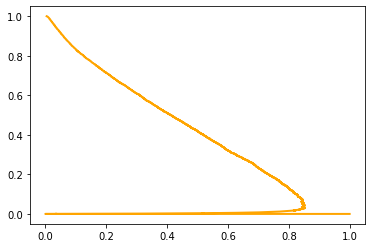

In [21]:
plt.plot(fpr_chrombpnet, tpr_chrombpnet,  linewidth=2, c='orange', label="AP="+str(round(roc_auc,2)))


In [3]:
np.mean(auprcs)

/users/anusri/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/users/anusri/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


nan

In [32]:
np.mean(aurocs)

0.982771777608949

In [33]:
np.mean(auprcs)

0.4181642496975783

In [34]:
np.mean(aurocs)

0.982771777608949

In [35]:
np.mean(aurocs)

0.982771777608949

In [36]:
np.std(aurocs)

0.0011435485450399805

In [37]:
np.round(np.std(aurocs),3)

0.001

In [38]:
np.round(np.std(auprcs),2)

0.01

In [39]:
np.round(np.mean(auprcs),2)

0.42

In [40]:
np.round(np.mean(aurocs),2)

0.98

In [41]:
np.round(np.std(aurocs),2)

0.0

In [ ]:
# 0.98,0.001
# 0.42,0.01

0.02681772645203823

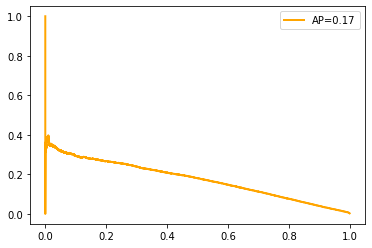

In [9]:
roc_auc = metrics.average_precision_score(chr1_binned["label"], chr1_binned["atac"])
print(roc_auc)

# #rom sklearn.metrics import roc_auc_score
# chr1_binned["atac"]

0.17496163323500602


In [21]:
# roc_auc_score(chr1_binned["label"],  abs(chr1_binned["atac"]))

0.8701539282294635

In [22]:
# import numpy as np
# from sklearn import metrics
# fpr, tpr, thresholds = metrics.roc_curve(chr1_binned["label"], chr1_binned["atac"])
# auc = metrics.auc(fpr, tpr)

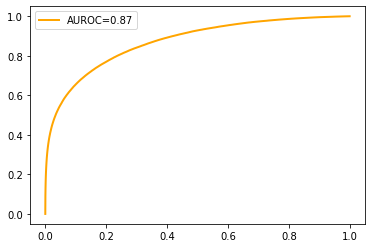

In [27]:
# plt.plot(fpr, tpr,  linewidth=2, c='orange', label="AUROC="+str(round(auc,2)))
# plt.legend()